In [248]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import torch.nn as nn
import torch
import torchmetrics
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score

### Load Dataset

In [249]:
dir = "dataset"
train_dataset = pd.read_csv(f"{dir}/train.csv")
test_dataset = pd.read_csv(f"{dir}/test.csv")

In [250]:
train_dataset.shape

(699635, 23)

In [251]:
train_dataset.head(3)

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False


In [252]:
train_dataset.columns

Index(['id', 'Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender',
       'Customer Type', 'Type of Travel', 'Class', 'satisfaction'],
      dtype='str')

### EDA

In [253]:
train_dataset.info()
# 23 Columns. 699635 rows.
# No Null values except in columns `Arrival Delay in Minutes`, 292 null values.
# 4 Strings, 1 Bool, 1 float, 17 int

<class 'pandas.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 699635 non-null  int64  
 1   Age                                699635 non-null  int64  
 2   Flight Distance                    699635 non-null  int64  
 3   Inflight wifi service              699635 non-null  int64  
 4   Departure/Arrival time convenient  699635 non-null  int64  
 5   Ease of Online booking             699635 non-null  int64  
 6   Gate location                      699635 non-null  int64  
 7   Food and drink                     699635 non-null  int64  
 8   Online boarding                    699635 non-null  int64  
 9   Seat comfort                       699635 non-null  int64  
 10  Inflight entertainment             699635 non-null  int64  
 11  On-board service                   699635 non-null

In [254]:
train_dataset.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,699635.00000,699635.000000,699635.000000,699635.000000,699635.00000,699635.00000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699343.000000
mean,349817.00000,39.001928,1353.778702,2.778722,3.15621,2.81324,3.013734,3.265644,3.364156,3.568950,3.453910,3.517404,3.472847,3.805443,3.420291,3.380401,1.176209,1.134280
std,201967.37213,13.800943,954.422566,1.280419,1.47539,1.32955,1.254014,1.300202,1.288538,1.275333,1.308157,1.238474,1.271755,1.079175,1.210604,1.277870,5.982187,5.749304
min,0.00000,7.000000,67.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,174908.50000,27.000000,631.000000,2.000000,2.00000,2.00000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,349817.00000,40.000000,954.000000,3.000000,3.00000,3.00000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,0.000000,0.000000
75%,524725.50000,50.000000,1814.000000,4.000000,4.00000,4.00000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,0.000000,0.000000
max,699634.00000,85.000000,4983.000000,5.000000,5.00000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,489.000000,491.000000


In [255]:
train_dataset.describe(include="str")

,Gender,Customer Type,Type of Travel,Class
count,699635,699635,699635,699635
unique,2,2,2,3
top,Male,Loyal Customer,Business travel,Business
freq,351683,576990,497441,342212


In [256]:
train_dataset.id.value_counts()
# Can drop id column
# Conclusion : Drop It.

id
0         1
1         1
2         1
3         1
4         1
         ..
699630    1
699631    1
699632    1
699633    1
699634    1
Name: count, Length: 699635, dtype: int64

In [257]:
train_dataset.Age.value_counts()
# Can probably Bin it.
# Conclusion : Dont Bin It.

Age
25    22387
39    22117
40    20082
41    19606
47    17999
      ...  
76       26
73       23
78       13
79       12
85        2
Name: count, Length: 75, dtype: int64

count    699635.000000
mean         39.001928
std          13.800943
min           7.000000
25%          27.000000
50%          40.000000
75%          50.000000
max          85.000000
Name: Age, dtype: float64


(array([158489., 188640., 176043., 176463.]),
 array([ 0., 27., 40., 50., 85.]),
 <BarContainer object of 4 artists>)

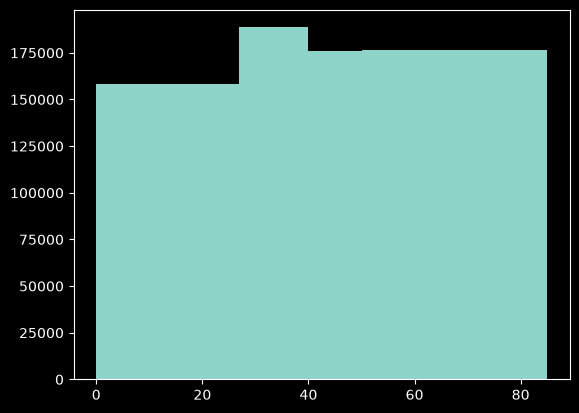

In [258]:
"""
7 to 85.
"""
print(train_dataset.Age.describe())
plt.hist(train_dataset.Age, bins=[0, 27, 40, 50, 85])

In [259]:
train_dataset["Flight Distance"].value_counts()
# Not sure, maybe Bin it
# Conclusion : Dont bin it.

Flight Distance
594     8176
862     6580
2475    6262
641     5646
689     5602
        ... 
487        1
1692       1
3002       1
1154       1
2048       1
Name: count, Length: 3474, dtype: int64

In [260]:
print(train_dataset["Flight Distance"].describe())

#plt.hist(train_dataset["Flight Distance"], bins=[0, 631, 954, 1814, 5000])

count    699635.000000
mean       1353.778702
std         954.422566
min          67.000000
25%         631.000000
50%         954.000000
75%        1814.000000
max        4983.000000
Name: Flight Distance, dtype: float64


In [261]:
train_dataset["Inflight wifi service"].value_counts()
# Ordinal Values. leave as it is
# Conclusion : Leave as it is

Inflight wifi service
2    186870
3    184436
4    128136
1    107739
5     79352
0     13102
Name: count, dtype: int64

In [262]:
train_dataset["Departure/Arrival time convenient"].value_counts()
# ordinal, leave as it is
# Conclusion : Leave as it is

Departure/Arrival time convenient
4    181530
5    156933
3    121640
2    118709
1     95072
0     25751
Name: count, dtype: int64

In [263]:
train_dataset["Ease of Online booking"].value_counts()
# ordinal, leave as it is
# Conclusion : Leave as it is

Ease of Online booking
3    175267
2    174868
4    130695
1    110934
5     91798
0     16073
Name: count, dtype: int64

In [264]:
train_dataset["Gate location"].value_counts()
# This is Might not be ordinal. Verify.
# If not, one hot encode.
# Conclusion : Leave as it is

Gate location
3    202277
4    168488
2    130300
1    104611
5     92504
0      1455
Name: count, dtype: int64

In [265]:
train_dataset["Food and drink"].value_counts()
# Is this Ordinal?
# Conclusion : Leave as it is

Food and drink
4    168861
5    155387
3    154557
2    148893
1     70923
0      1014
Name: count, dtype: int64

In [266]:
train_dataset["Online boarding"].value_counts()
# Is this ordinal?
# Conclusion : Leave as it is

Online boarding
4    210950
5    152870
3    149783
2    119297
1     57588
0      9147
Name: count, dtype: int64

In [267]:
train_dataset["Seat comfort"].value_counts()
# This is ordinal
# Conclusion : Leave as it is

Seat comfort
4    226726
5    196288
3    120182
2     92471
1     63130
0       838
Name: count, dtype: int64

In [268]:
train_dataset["Inflight entertainment"].value_counts()
# is this ordinal?
# Conclusion : Leave as it is

Inflight entertainment
4    210098
5    182068
3    122977
2    113341
1     70131
0      1020
Name: count, dtype: int64

In [269]:
train_dataset["On-board service"].value_counts()
# This is ordinal
# Conclusion : Leave as it is

On-board service
4    225949
5    173895
3    150812
2     87014
1     61164
0       801
Name: count, dtype: int64

In [270]:
train_dataset["Leg room service"].value_counts()
# This is ordinal
# Conclusion : Leave as it is

Leg room service
4    204124
5    182369
3    131580
2    126775
1     53094
0      1693
Name: count, dtype: int64

In [271]:
train_dataset["Baggage handling"].value_counts()
# This is ordinal
# Conclusion : Leave as it is

Baggage handling
4    277622
5    202673
3    130348
2     58532
1     30460
Name: count, dtype: int64

In [272]:
train_dataset["Checkin service"].value_counts()
# This is ordinal
# Conclusion : Leave as it is

Checkin service
4    209592
3    200177
5    147550
2     74919
1     66468
0       929
Name: count, dtype: int64

In [273]:
train_dataset["Cleanliness"].value_counts()
# This is ordinal
# Conclusion : Leave as it is

Cleanliness
4    190681
3    169931
5    162964
2    102596
1     72518
0       945
Name: count, dtype: int64

In [274]:
train_dataset["Departure Delay in Minutes"].value_counts()
# This is Min. Higher the value, More disappointed customer. Treat it as Ordinal
# Conclusion : Leave as it is

Departure Delay in Minutes
0      635152
1        8240
2        5781
3        4382
4        3869
        ...  
221         1
231         1
228         1
88          1
79          1
Name: count, Length: 167, dtype: int64

In [275]:
train_dataset["Arrival Delay in Minutes"].value_counts()
# This is Min. Higher the value, More disappointed customer. Treat it as Ordinal
# It has Null Values. Fill it with 0.0
# Conclusion : Fill Null by 0.0


Arrival Delay in Minutes
0.0      640415
1.0        4546
2.0        4141
3.0        3881
4.0        3612
          ...  
122.0         1
120.0         1
103.0         1
227.0         1
76.0          1
Name: count, Length: 168, dtype: int64

In [276]:
train_dataset["Gender"].value_counts()
# Categorical Encode based on Algorithm
# Conclusion : One hot Encode

Gender
Male      351683
Female    347952
Name: count, dtype: int64

In [277]:
train_dataset["Customer Type"].value_counts()
# Categorical Encode based on Algorithm
# Conclusion : One hot Encode

Customer Type
Loyal Customer       576990
disloyal Customer    122645
Name: count, dtype: int64

In [278]:
train_dataset["Type of Travel"].value_counts()
# Categorical Encode based on Algorithm
# Conclusion : One hot Encode

Type of Travel
Business travel    497441
Personal Travel    202194
Name: count, dtype: int64

In [279]:
train_dataset["Class"].value_counts()
# Categorical Encode based on Algorithm
# Conclusion : One hot Encode

Class
Business    342212
Eco         327404
Eco Plus     30019
Name: count, dtype: int64

In [280]:
train_dataset["satisfaction"].value_counts()
# This is the Target. Encode 0 for False and 1 for True.
# Conclusion : Encode 0 for False and 1 for True

satisfaction
False    389296
True     310339
Name: count, dtype: int64

In [281]:
"""
Conclusion :

Columns                                 Changes
id                                      Drop The column
Age                                     Standardize Data
Flight Distance                         Standardize Data
Inflight wifi service                   No Change
Departure/Arrival time convenient       No Change
Ease of Online booking                  No Change
Gate location                           No Change
Food and drink                          No Change
Online boarding                         No Change
Seat comfort                            No Change
Inflight entertainment                  No Change
On-board service                        No Change
Leg room service                        No Change
Baggage handling                        No Change
Checkin service                         No Change
Cleanliness                             No Change
Departure Delay in Minutes              Standardize Data
Arrival Delay in Minutes                Fill NA by 0 & Standardize Data
Gender                                  One hot Encode
Customer Type                           One hot Encode
Type of Travel                          One hot Encode
Class                                   One hot Encode
satisfaction                            Binary Encode (0/1): Target
"""

'\nConclusion :\n\nColumns                                 Changes\nid                                      Drop The column\nAge                                     Standardize Data\nFlight Distance                         Standardize Data\nInflight wifi service                   No Change\nDeparture/Arrival time convenient       No Change\nEase of Online booking                  No Change\nGate location                           No Change\nFood and drink                          No Change\nOnline boarding                         No Change\nSeat comfort                            No Change\nInflight entertainment                  No Change\nOn-board service                        No Change\nLeg room service                        No Change\nBaggage handling                        No Change\nCheckin service                         No Change\nCleanliness                             No Change\nDeparture Delay in Minutes              Standardize Data\nArrival Delay in Minutes              

### Data Preprocessing

In [282]:
columns_to_drop = ["id"]
columns_to_standard = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
columns_no_change = ["Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking", "Gate location", "Food and drink",
                    "Online boarding", "Seat comfort", "Inflight entertainment", "On-board service", "Leg room service", "Baggage handling", "Checkin service","Cleanliness"]
columns_to_fill_na = ["Arrival Delay in Minutes"]
columns_to_one_hot_encode = ["Gender", "Customer Type", "Type of Travel", "Class"]
columns_to_one_hot_encode.extend(columns_no_change)
columns_to_binary_encode = ["satisfaction"]

In [283]:
len(train_dataset.columns)

23

In [284]:
len(columns_to_drop) + len(columns_to_standard) + len(columns_no_change) + len(columns_to_one_hot_encode) + len(columns_to_binary_encode)

36

In [285]:
train_dataset.drop(columns_to_drop, inplace=True, axis=1)

In [286]:
train_data, val_data = train_test_split(train_dataset, test_size=0.2)
train_dataset.shape, train_data.shape, val_data.shape

((699635, 22), (559708, 22), (139927, 22))

In [287]:
train_data

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
292364,28,594,5,5,5,1,5,5,4,5,...,5,4,5,0,0.0,Female,disloyal Customer,Business travel,Business,True
157629,49,859,3,2,3,3,5,3,4,2,...,2,4,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
221866,46,761,3,5,3,1,4,5,4,4,...,5,3,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
299503,36,1399,4,4,4,4,2,4,1,4,...,5,4,4,0,0.0,Male,Loyal Customer,Business travel,Business,True
373225,14,541,5,4,5,2,2,5,2,2,...,5,3,2,0,0.0,Female,Loyal Customer,Personal Travel,Eco,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45795,51,1723,2,2,2,2,3,4,4,5,...,5,5,4,0,0.0,Female,Loyal Customer,Business travel,Business,True
214908,48,528,4,1,1,1,2,5,1,4,...,4,4,3,0,0.0,Female,Loyal Customer,Business travel,Eco,True
400500,27,936,4,4,4,3,1,4,1,1,...,4,3,1,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
503921,38,240,2,2,2,2,5,4,3,2,...,2,2,3,0,0.0,Male,Loyal Customer,Business travel,Business,False


In [288]:
X_train = train_data.drop("satisfaction", axis=1)
y_train = train_data["satisfaction"]

X_valid = val_data.drop("satisfaction", axis=1)
y_valid = val_data["satisfaction"]

X_test = test_dataset

In [289]:
preprocessor = ColumnTransformer(transformers=[
    ("standardize", Pipeline([("fillna", SimpleImputer(strategy="constant", fill_value=0.0)), ("standardize", StandardScaler())]), columns_to_standard),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), columns_to_one_hot_encode)], remainder="passthrough", verbose_feature_names_out=False)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardize', ...), ('one_hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

In [290]:
X_train = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)

X_valid = pd.DataFrame(
    preprocessor.transform(X_valid),
    columns=preprocessor.get_feature_names_out(),
    index=X_valid.index
)

X_test = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

In [291]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_train = pd.DataFrame(label_encoder.transform(y_train), index=X_train.index)

y_valid = pd.DataFrame(label_encoder.transform(y_valid), index=X_valid.index)

In [292]:
X_train

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,...,Checkin service_2,Checkin service_3,Checkin service_4,Checkin service_5,Cleanliness_0,Cleanliness_1,Cleanliness_2,Cleanliness_3,Cleanliness_4,Cleanliness_5
292364,-0.797359,-0.796217,-0.196027,-0.196741,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
157629,0.724300,-0.518619,-0.196027,-0.196741,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
221866,0.506921,-0.621278,-0.196027,-0.196741,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
299503,-0.217679,0.047054,-0.196027,-0.196741,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
373225,-1.811798,-0.851737,-0.196027,-0.196741,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45795,0.869220,0.386457,-0.196027,-0.196741,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
214908,0.651840,-0.865355,-0.196027,-0.196741,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
400500,-0.869819,-0.437958,-0.196027,-0.196741,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
503921,-0.072759,-1.167047,-0.196027,-0.196741,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [293]:
y_train

,0
292364,1
157629,0
221866,0
299503,1
373225,1
...,...
45795,1
214908,1
400500,0
503921,0


### Model - MLP

In [294]:
model = nn.Sequential(nn.Linear(90, 256, dtype=torch.float64), nn.Tanh(), nn.Linear(256, 256, dtype=torch.float64), nn.Tanh(),
                      nn.Linear(256, 128, dtype=torch.float64), nn.Tanh(), nn.Linear(128, 64, dtype=torch.float64), nn.Tanh(),
                      nn.Linear(64, 1, dtype=torch.float64))
model

Sequential(
  (0): Linear(in_features=90, out_features=256, bias=True)
  (1): Tanh()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): Tanh()
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): Tanh()
  (6): Linear(in_features=128, out_features=64, bias=True)
  (7): Tanh()
  (8): Linear(in_features=64, out_features=1, bias=True)
)

In [295]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)
xentropy = nn.BCEWithLogitsLoss()
ROC = torchmetrics.ROC(task="binary", num_classes=2)

In [296]:
n_epochs = 30
batch_size = 32
X_train = torch.from_numpy(np.array(X_train, dtype="float64"))
y_train = torch.from_numpy(np.array(y_train, dtype="float64").reshape(-1, 1))
train_batch_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_batch_data, batch_size=batch_size, shuffle=True)


X_val = torch.from_numpy(np.array(X_valid, dtype="float64"))
y_val = torch.from_numpy(np.array(y_valid, dtype="float64").reshape(-1, 1))
val_batch_data = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_batch_data, batch_size=batch_size, shuffle=True)

X_test = torch.from_numpy(np.array(X_test, dtype="float64"))
test_batch_data = TensorDataset(X_test)
test_loader = DataLoader(test_batch_data, batch_size=batch_size, shuffle=True)

In [297]:
def train(model, optimizer, criterion, train_loader, val_loader, n_epochs):
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.
        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        model.eval()
        val_loss = 0.0
        all_probs = []
        all_targets = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                y_prob = torch.sigmoid(y_pred)
                all_probs.append(y_prob.cpu())
                all_targets.append(y_batch.cpu())
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        all_probs = torch.cat(all_probs).numpy()
        all_targets = torch.cat(all_targets).numpy()
        val_roc = roc_auc_score(all_targets, all_probs)
        val_loss /= len(val_loader)
        mean_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Validation Loss: {val_loss:.4f}, Validation ROC-AUC: {val_roc:.4f}")

In [ ]:
train(model, optimizer, xentropy, train_loader, val_loader, n_epochs)

Epoch 1/30, Loss: 0.2829, Validation Loss: 0.2610, Validation ROC-AUC: 0.9499
Epoch 2/30, Loss: 0.2637, Validation Loss: 0.2590, Validation ROC-AUC: 0.9501
Epoch 3/30, Loss: 0.2608, Validation Loss: 0.2546, Validation ROC-AUC: 0.9518
Epoch 4/30, Loss: 0.2528, Validation Loss: 0.2470, Validation ROC-AUC: 0.9534


### Model - Random Forest